In [2]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

Carga imagen desde archivo con OpenCV

In [3]:
#Lee imagen de archivo
img = cv2.imread('mandril.jpg') 

Convierte la imagen a grises para procesamiento posterior

Cuenta el número de píxeles no nulos por columna y visualiza el vector resultante

(0.0, 512.0)

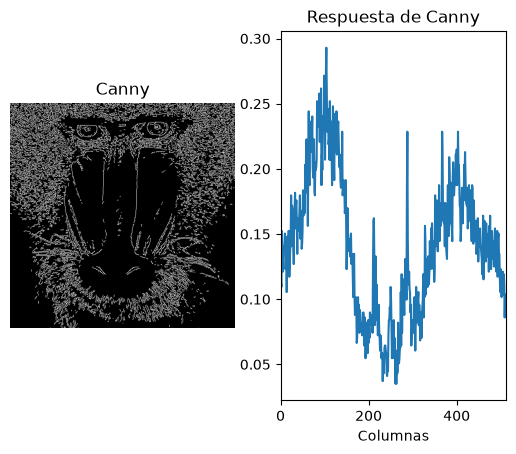

In [4]:
#El contenido de la imagen resultado de Canny, son valores 0 o 255, lo compruebas al descomentar
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gris, 180, 250) #prueba a jugar con umbrales (entre 0 y 255)


#Cuenta el número de píxeles blancos (255) por columna
#Suma los valores de los pixeles por columna
col_counts = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

#Normaliza en base al número de filas, primer valor devuelto por shape, y al valor máximo del píxel (255)
#El resultado será el número de píxeles blancos por columna
cols = col_counts[0] / (255 * canny.shape[0])

#Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray') 

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.plot(cols)
#Rango en x definido por las columnas
plt.xlim([0, canny.shape[1]])

TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

(0.0, 512.0)

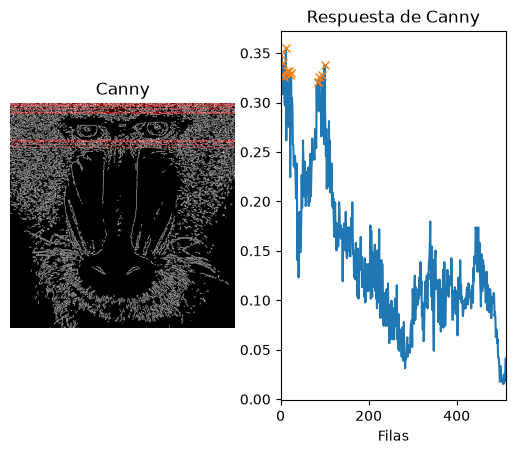

In [42]:
canny_t = canny.transpose((1, 0))

row_counts = cv2.reduce(canny_t, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

rows = row_counts[0] / (255 * canny.shape[0])
maxfil = max(row_counts[0]) / 255

filtered_x = [i for i in range(canny.shape[0]) if row_counts[0, i] / 255 >= maxfil * 0.9]
filtered_y = [rows[i] for i in range(canny.shape[0]) if row_counts[0, i] / 255 >= maxfil * 0.9]

rgb_image = cv2.cvtColor(canny, cv2.COLOR_GRAY2RGB)
for i in filtered_x:
    rgb_image[i, :, 0] = 255
#Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(rgb_image) 

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rows, '-')
plt.plot(filtered_x, filtered_y, 'x')
plt.xlim([0, canny.shape[1]])

In [6]:
img = cv2.imread('mandril.jpg') 
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Gaussiana para suavizar la imagen original, eliminando altas frecuencias
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

#Calcula en ambas direcciones (horizontal y vertical)
sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)  # y
#Combina ambos resultados
sobel = cv2.add(sobelx, sobely)
sobel8np = np.uint8(np.abs(sobel))


TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

(0.0, 512.0)

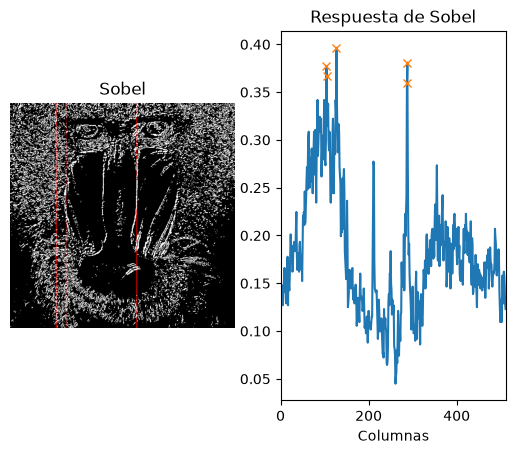

In [7]:

threshold = 100 
_, img_after_threshold = cv2.threshold(sobel8np, threshold, 255, cv2.THRESH_BINARY)

col_counts = cv2.reduce(img_after_threshold, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

cols = col_counts[0] / (255 * canny.shape[0])

maxcol = max(col_counts[0]) / 255
filtered_x_cols = [i for i in range(512) if col_counts[0, i] / 255 >= maxcol * 0.9]
filtered_y_cols = [cols[i] for i in range(512) if col_counts[0, i] / 255 >= maxcol * 0.9]

sobelcp = np.copy(img_after_threshold)
rgb_image = cv2.cvtColor(img_after_threshold, cv2.COLOR_GRAY2RGB)
for i in filtered_x_cols:
    rgb_image[:, i, 0] = 255

plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Sobel")
plt.imshow(rgb_image) 

plt.subplot(1, 2, 2)

plt.title("Respuesta de Sobel")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.plot(cols)
plt.plot(filtered_x_cols, filtered_y_cols, 'x')
plt.xlim([0, canny.shape[1]])


(0.0, 512.0)

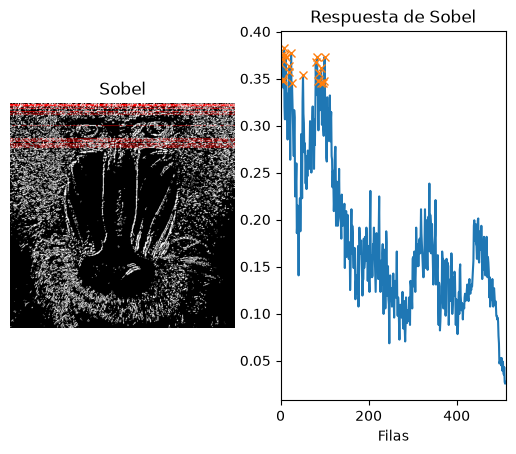

In [8]:

threshold = 100 
_, img_after_threshold = cv2.threshold(sobel8np, threshold, 255, cv2.THRESH_BINARY)
sobel_t = img_after_threshold.transpose((1, 0))
row_counts = cv2.reduce(sobel_t, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

rows = row_counts[0] / (255 * canny.shape[0])

maxfil = max(row_counts[0]) / 255
filtered_x_rows = [i for i in range(512) if row_counts[0, i] / 255 >= maxfil * 0.9]
filtered_y_rows = [rows[i] for i in range(512) if row_counts[0, i] / 255 >= maxfil * 0.9]
sobelcp = np.copy(img_after_threshold)
rgb_image = cv2.cvtColor(img_after_threshold, cv2.COLOR_GRAY2RGB)
for i in filtered_x_rows:
    rgb_image[i, :, 0] = 255

plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Sobel")
plt.imshow(rgb_image) 

plt.subplot(1, 2, 2)

plt.title("Respuesta de Sobel")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(rows)
plt.plot(filtered_x_rows, filtered_y_rows, 'x')
plt.xlim([0, canny.shape[1]])

Diferencia de imágenes

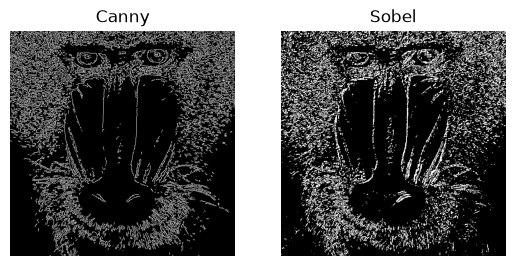

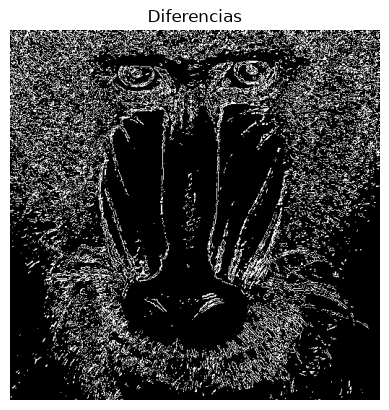

In [9]:
dif = cv2.absdiff(canny, img_after_threshold)

plt.figure()
plt.subplot(1, 2, 1)
plt.title("Canny")
plt.axis("off")
plt.imshow(canny, cmap='gray') 

plt.subplot(1, 2, 2)
plt.title("Sobel")
plt.axis("off")
plt.imshow(img_after_threshold, cmap='gray') 


plt.figure()
plt.title("Diferencias")
plt.axis("off")
plt.imshow(dif, cmap='gray') 


TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

In [ ]:
vid = cv2.VideoCapture(0)
ball_x = 0
ball_y = 0
ball_size = 30
vx = 2
vy = 2
f = 0

friction = 0.9999
#Marca de inicio
_, pframe = vid.read()
height, width = pframe.shape[:2]
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()
    f += 1
    if f > 600:
        f = 0
        ball_y = 0
    if ret:
        ball_x += vx
        ball_y += vy


        # Handle ball and screen border bounce
        if ball_x - ball_size < 0:
            ball_x = ball_size
            vx *= -1

        if ball_x + ball_size > width:
            ball_x = width - ball_size
            vx *= -1

        if ball_y - ball_size < 0:
            ball_y = ball_size
            vy *= -1

        if ball_y + ball_size > height:
            ball_y = height - ball_size
            vy *= -1

        vx *= friction
        vy *= friction
        
        frame = cv2.flip(frame, 1)
        dif = cv2.absdiff(frame, pframe)        
        #Calcula en ambas direcciones (horizontal y vertical)
        sobelx = cv2.Sobel(dif, cv2.CV_64F, 1, 0)  # x
        sobely = cv2.Sobel(dif, cv2.CV_64F, 0, 1)  # y
        #Combina ambos resultados
        sobel = cv2.add(sobelx, sobely)

        
        sobel8np = np.uint8(np.abs(sobel))
        for i in range(0, ball_size):
            

        cv2.circle(dif, (int(ball_x), int(ball_y)), ball_size, (100,100,205), -1)
        
        cv2.imshow('Diferencia', dif)    
        #Copia fotograma actual para la diferencia en el siguiente forograma
    pframe = frame.copy()
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()